In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('us_cleaned.csv')
df.head()

,Unnamed: 0,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,...,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Temperature(C),Wind_Chill(C)
0,295462,A-295470,2,2016-08-18 08:20:31,2016-08-18 09:05:31,30.088078,-96.013050,0.00,Hempstead,Waller,...,False,False,False,False,False,False,Day,Day,25.000000,0.000000
1,291275,A-291283,2,2016-10-16 11:29:41,2016-10-16 11:59:23,30.100855,-96.073630,0.00,Hempstead,Waller,...,False,False,False,False,False,False,Day,Day,29.777779,0.000000
2,263417,A-263424,3,2016-12-10 07:42:13,2016-12-10 08:11:31,30.099180,-96.041245,0.01,Hempstead,Waller,...,False,False,False,False,False,False,Day,Day,4.888889,3.777778
3,263418,A-263425,3,2016-12-10 07:42:51,2016-12-10 08:12:18,30.099180,-96.041245,0.01,Hempstead,Waller,...,False,False,False,False,False,False,Day,Day,4.888889,3.777778
4,263439,A-263446,2,2016-12-10 10:43:07,2016-12-10 11:27:39,30.099180,-96.041245,0.01,Hempstead,Waller,...,False,False,False,False,False,False,Day,Day,8.611111,0.000000


## Infrastructure routière

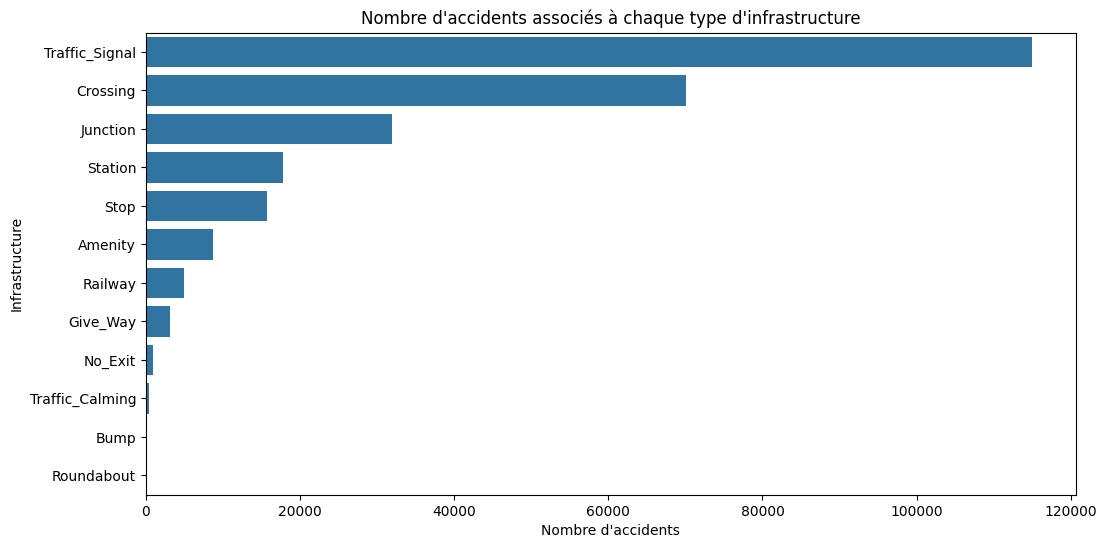

In [2]:
# Distribution des types d'infrastructure
infra_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
              'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
              'Traffic_Calming', 'Traffic_Signal']

infra_counts = df[infra_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=infra_counts.values, y=infra_counts.index)
plt.title("Nombre d'accidents associés à chaque type d'infrastructure")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Infrastructure")
plt.show()

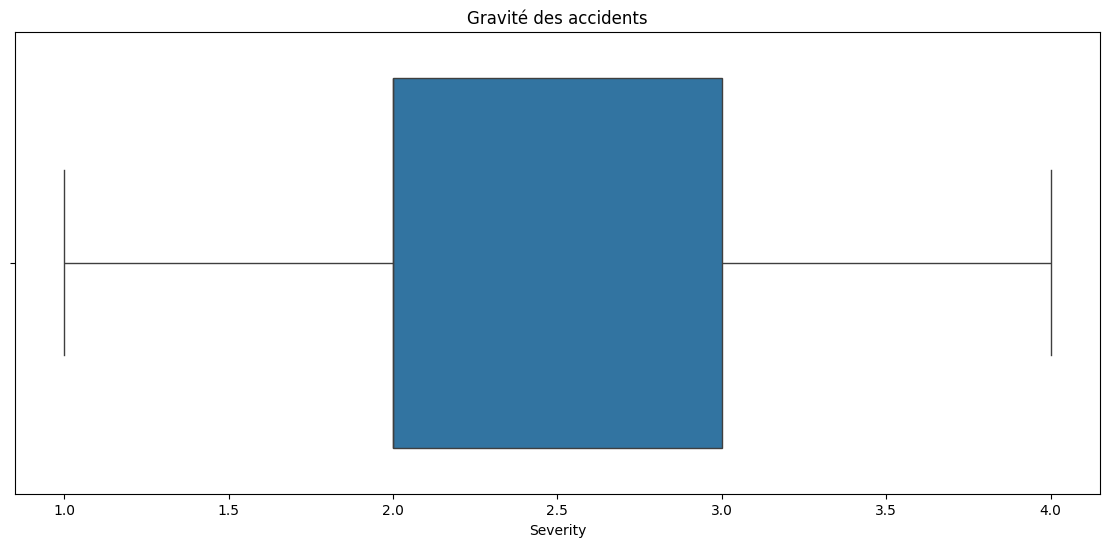

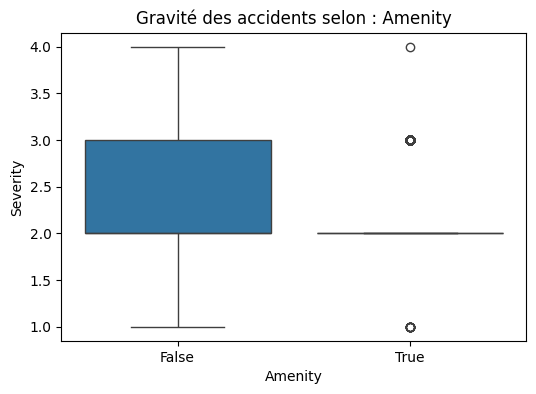

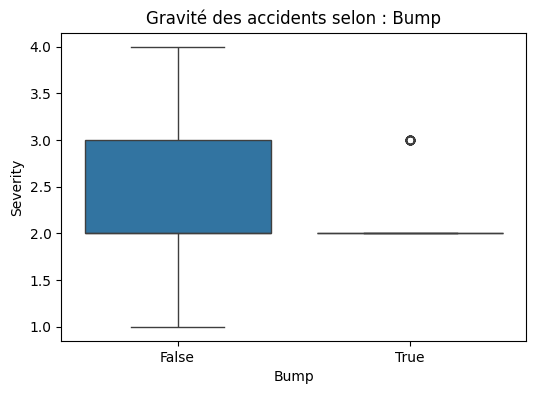

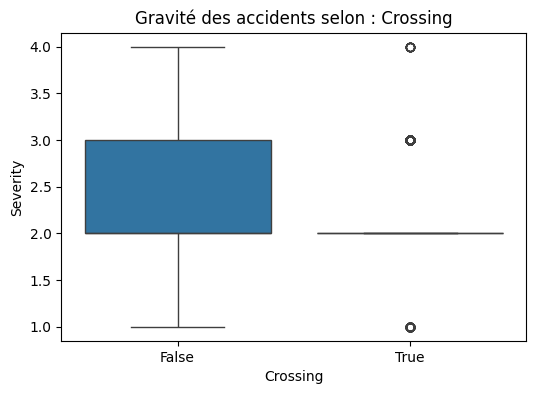

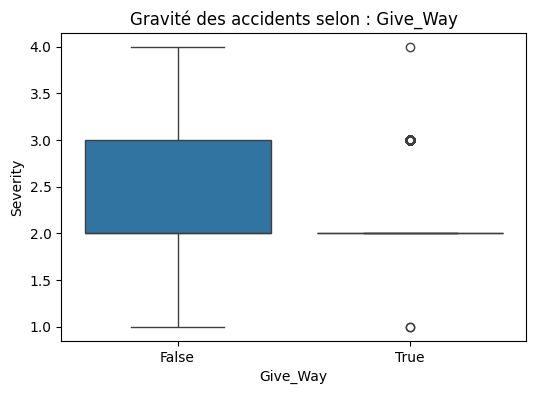

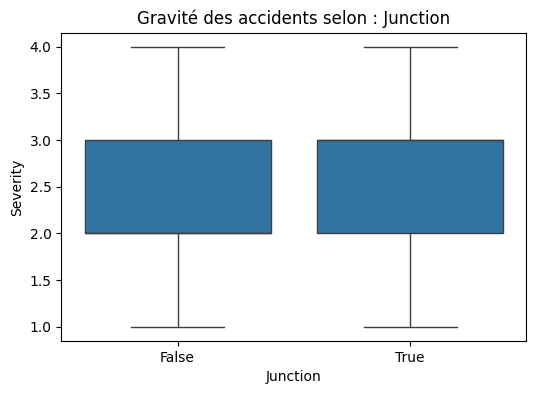

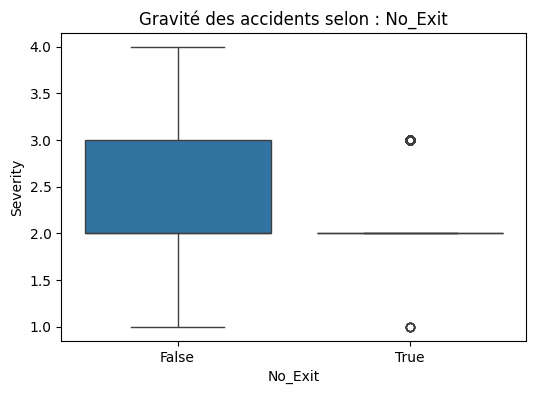

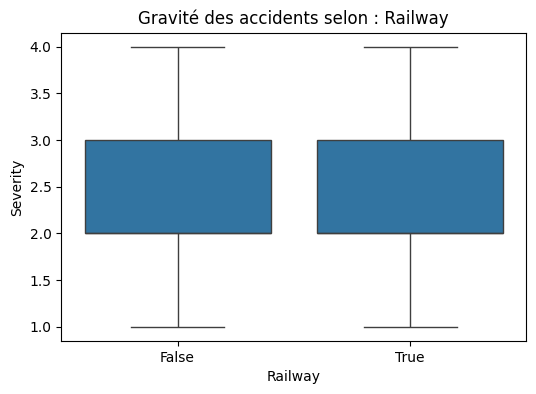

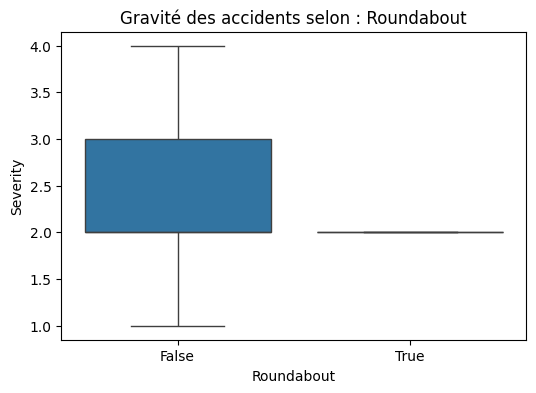

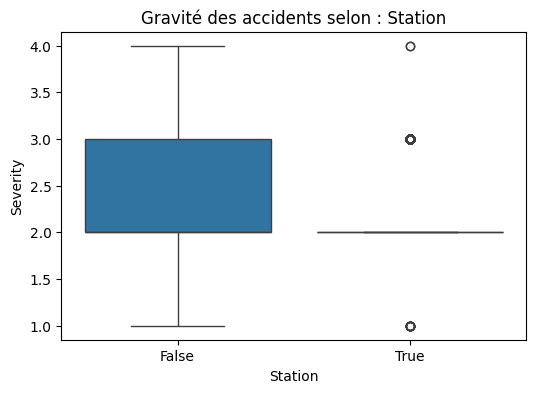

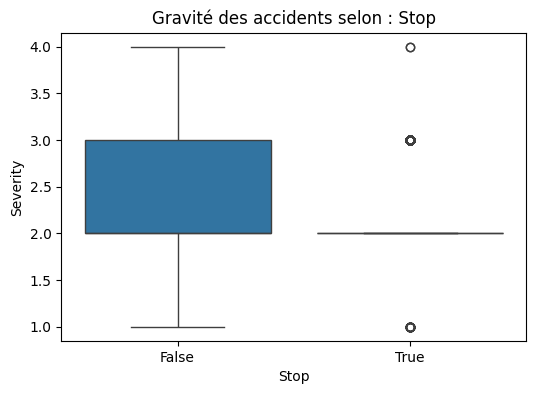

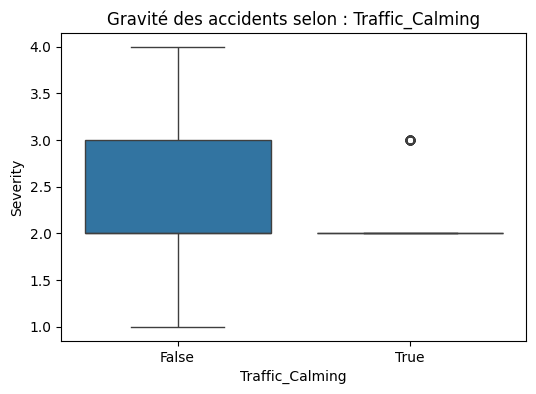

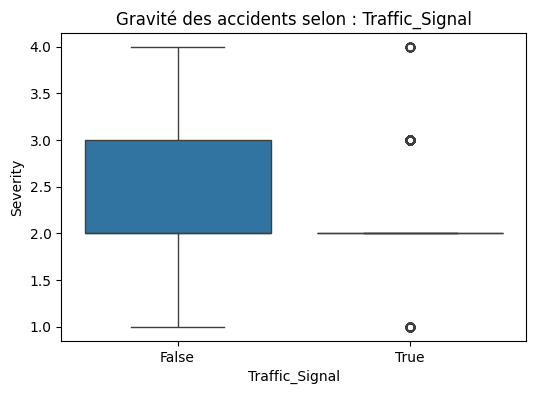

In [3]:
#Gravité des accidents selon l’infrastructure
plt.figure(figsize=(14,6))
sns.boxplot(data=df[infra_cols + ['Severity']], x='Severity')
plt.title("Gravité des accidents")
plt.show()

# Boxplots par infrastructure
for col in infra_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df['Severity'])
    plt.title(f"Gravité des accidents selon : {col}")
    plt.xlabel(col)
    plt.ylabel("Severity")
    plt.show()

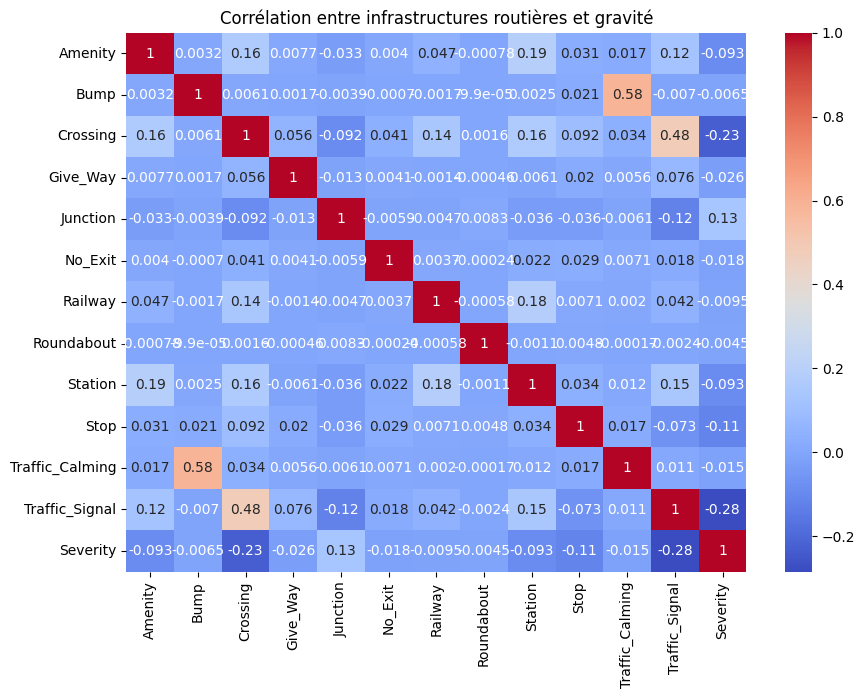

In [4]:
# Corrélation entre infrastructures et gravité
corr = df[infra_cols + ['Severity']].corr(method='spearman')

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Corrélation entre infrastructures routières et gravité")
plt.show()

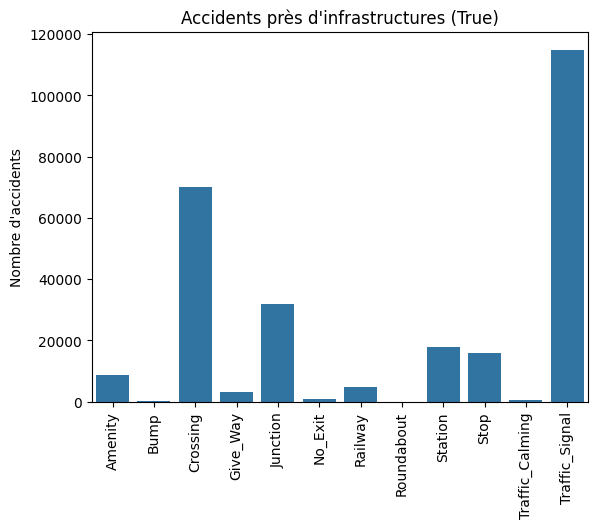

In [5]:
# Analyse accidents avec / sans infrastructure

infra_acc_counts = {
    col: df[df[col] == True].shape[0] for col in infra_cols
}

sns.barplot(
    x=list(infra_acc_counts.keys()),
    y=list(infra_acc_counts.values())
)
plt.xticks(rotation=90)
plt.title("Accidents près d'infrastructures (True)")
plt.ylabel("Nombre d'accidents")
plt.show()


In [7]:
# Carte : localisation des accidents près de certaines infrastructures

import folium
from folium.plugins import HeatMap

m = folium.Map(location=[df.Start_Lat.mean(), df.Start_Lng.mean()], zoom_start=5)

heat_data = df[df['Junction'] == True][['Start_Lat','Start_Lng']].values.tolist()

HeatMap(heat_data).add_to(m)

m
